Cloning into 'ace-minimum-energy-criterion'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 87 (delta 26), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 883.67 KiB | 11.63 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Subspace rank: 3
aligned: O(z) = 0.000000
slightly_drifting: O(z) = 0.000000
hallucinated: O(z) = 0.000000


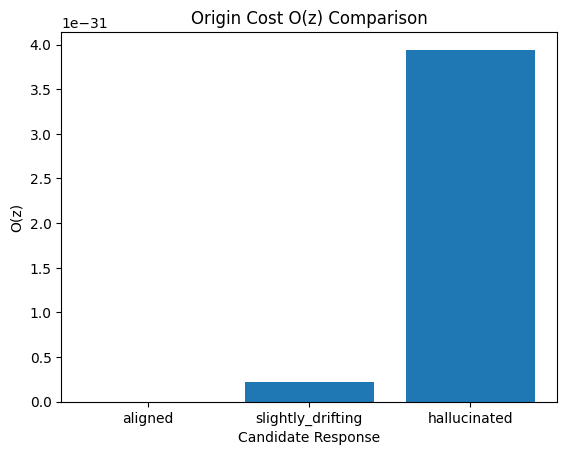


Best candidate:
aligned


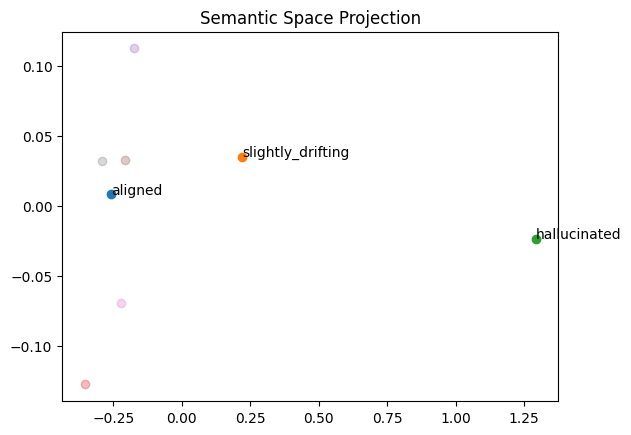


ACE demonstrates that:

- Not all responses are equal in semantic stability
- Alignment with origin reduces hallucination risk
- O(z) provides a deterministic signal for response selection

This transforms language generation from sampling → convergence.



In [4]:
# ACE: Semantic Convergence Demo
# Author: Ernesto Rosati Beristain
# DOI: https://doi.org/10.5281/zenodo.19162999

"""
This notebook demonstrates how ACE (Axiomatic Criterion Engine)
selects the most semantically stable response by minimizing Origin Cost O(z).

Core idea:
Language generation is a minimum-energy convergence process.
"""

!git clone https://github.com/rosatisoft/ace-minimum-energy-criterion.git

import sys
sys.path.append('/content/ace-minimum-energy-criterion')

import numpy as np
import matplotlib.pyplot as plt

from ace.core.scorer import ACEScorer
from ace.core.subspace import build_reference_subspace
from ace.core.origin_cost import compute_origin_cost

# Synthetic but structured semantic space

prompt = np.array([1.0, 0.9, 0.1])

axioms = [
    np.array([0.9, 1.0, 0.0]),
    np.array([1.0, 0.8, 0.2])
]

knowledge = [
    np.array([0.95, 0.85, 0.15]),
    np.array([0.88, 0.92, 0.12])
]

subspace = build_reference_subspace(
    prompt_embedding=prompt,
    axiom_embeddings=axioms,
    knowledge_embeddings=knowledge
)

basis = subspace.basis
centroid = subspace.centroid

print("Subspace rank:", subspace.rank)

# Candidate responses

candidates = {
    "aligned": np.array([0.96, 0.89, 0.11]),
    "slightly_drifting": np.array([0.7, 0.6, 0.4]),
    "hallucinated": np.array([0.1, 0.2, 1.2])
}

results = {}

for name, vec in candidates.items():
    result = compute_origin_cost(
        vec,
        subspace_result=subspace
    )

    results[name] = result
    print(f"{name}: O(z) = {result.origin_cost:.6f}")

    labels = []
values = []

for name, res in results.items():
    labels.append(name)
    values.append(res.origin_cost)

plt.figure()
plt.bar(labels, values)
plt.title("Origin Cost O(z) Comparison")
plt.ylabel("O(z)")
plt.xlabel("Candidate Response")
plt.show()

best = min(results.items(), key=lambda x: x[1].origin_cost)

print("\nBest candidate:")
print(best[0])

# Project everything to 2D for visualization

from sklearn.decomposition import PCA

all_vectors = list(candidates.values()) + axioms + knowledge + [prompt]

pca = PCA(n_components=2)
reduced = pca.fit_transform(all_vectors)

# Split back
candidate_points = reduced[:3]
context_points = reduced[3:]

plt.figure()

# Plot candidates
for i, name in enumerate(candidates.keys()):
    plt.scatter(candidate_points[i,0], candidate_points[i,1])
    plt.text(candidate_points[i,0], candidate_points[i,1], name)

# Plot context
for pt in context_points:
    plt.scatter(pt[0], pt[1], alpha=0.3)

plt.title("Semantic Space Projection")
plt.show()

print("""
ACE demonstrates that:

- Not all responses are equal in semantic stability
- Alignment with origin reduces hallucination risk
- O(z) provides a deterministic signal for response selection

This transforms language generation from sampling → convergence.
""")